In [2]:
#importation des modules
import torch
from torchvision.models import ResNet18_Weights
import torchvision.models as models
import numpy as np
from torchvision.transforms import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.utils.data import random_split    
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import Subset
from torch.utils.data import WeightedRandomSampler
from collections import Counter


In [9]:
# Génération des données équilibrées
# Transformation des données
destination_data="/home/onyxia/data/MINI-DDSM/MINI-DDSM-Complete-JPEG-82/"

transform = transforms.Compose([
    transforms.Resize((900, 900)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

data_set = ImageFolder(root=destination_data, transform=transform)
label = np.array(data_set.targets)

print(f"Nombre total d'images : {len(label)}")
print(f"Classes détectées : {data_set.classes}")
print(f"Distribution des classes : {Counter(label)}")

# Split stratifié des données
numero_random = 42
train_size = 0.7
val_size = 0.15
test_size = 0.15

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=numero_random)
for train_val_index, test_index in sss1.split(np.zeros(len(label)), label):
    train_val_indices = train_val_index
    test_indices = test_index

train_val_labels = label[train_val_indices]
new_val_size = val_size / (train_size + val_size)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=new_val_size, random_state=numero_random)
for train_index, val_index in sss2.split(np.zeros(len(train_val_labels)), train_val_labels):
    train_indices = train_val_indices[train_index]
    val_indices = train_val_indices[val_index]

print(f"Train set: {len(train_indices)}")
print(f"Validation set: {len(val_indices)}")
print(f"Test set: {len(test_indices)}")

# Weighted Sampler pour équilibrer les classes
train_labels = label[train_indices]
class_counts = Counter(train_labels)
print(f"Distribution dans train : {class_counts}")

num_labels = len(train_labels)
weight_for_class = {cl: num_labels / count for cl, count in class_counts.items()}
sample_weights = [weight_for_class[l] for l in train_labels]
sample_weights_tensor = torch.DoubleTensor(sample_weights)

print(f"Poids par classe : {weight_for_class}")

sampler = WeightedRandomSampler(
    weights=sample_weights_tensor, 
    num_samples=len(sample_weights_tensor), 
    replacement=True
)

train_set = Subset(data_set, train_indices)
val_set = Subset(data_set, val_indices)
test_set = Subset(data_set, test_indices)

bs = 16
train_loader = DataLoader(train_set, batch_size=bs, num_workers=4, pin_memory=True, sampler=sampler)
val_loader = DataLoader(val_set, batch_size=bs, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=bs, shuffle=False, num_workers=4, pin_memory=True)

Nombre total d'images : 3666
Classes détectées : ['0-normal', '1-cancer_benign']
Distribution des classes : Counter({np.int64(0): 2333, np.int64(1): 1333})
Train set: 2566
Validation set: 550
Test set: 550
Distribution dans train : Counter({np.int64(0): 1633, np.int64(1): 933})
Poids par classe : {np.int64(1): 2.7502679528403, np.int64(0): 1.571341090018371}


In [10]:
#attention, donnees equilibrees? AUC COMPARABle? oui avec l'AUC
#attention également aux conventions : classe positive =1 classe normale/négative = 0
#génération des données équilibrées

#standardisation de la transformation des images pour coller au modèle restnet18
transform = transforms.Compose([
    transforms.Resize((900, 900)),
    #transforms.Lambda(lambda x: x.convert('RGB')),
    transforms.ToTensor(),
    #transforms.Lambda(lambda x: x.to(torch.float32)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
data_set=ImageFolder(root="/home/onyxia/work/dataset_vindr", transform=transform)
label=np.array(data_set.targets)
print(len(label))
print(label.sum()/len(label))

bs=16
test_loader_vindr = DataLoader(
    data_set, 
    batch_size=bs,       # Augmente le batch_size si possible (ex: 64 ou 128)
    shuffle=False, 
    num_workers=4,       # <--- ESSENTIEL : utilise plusieurs cœurs CPU
    pin_memory=True      # <--- Accélère le transfert CPU vers GPU
)
#test_loader = DataLoader(data_set, batch_size=bs, shuffle=False)


9999
0.32963296329632963


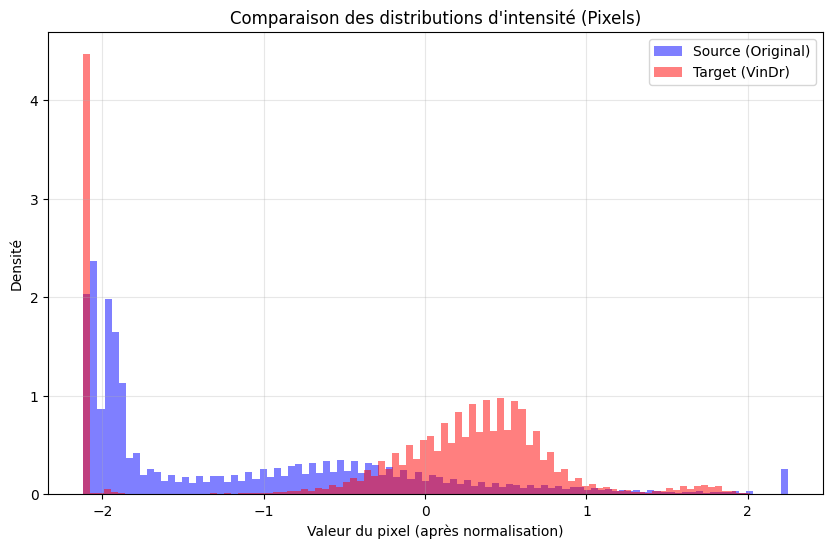

In [11]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def plot_distributions(loader_source, loader_target, n_batches=5):
    # On récupère quelques données pour avoir une distribution stable
    source_pixels = []
    target_pixels = []
    
    with torch.no_grad():
        # Extraction du domaine Source
        for i, (images, _) in enumerate(loader_source):
            if i >= n_batches: break
            # On prend un seul canal (gris) et on aplatit
            source_pixels.extend(images[:, 0, :, :].flatten().numpy())
            
        # Extraction du domaine Cible (VinDr)
        for i, (images, _) in enumerate(loader_target):
            if i >= n_batches: break
            target_pixels.extend(images[:, 0, :, :].flatten().numpy())

    # Création du graphique
    plt.figure(figsize=(10, 6))
    plt.hist(source_pixels, bins=100, alpha=0.5, label='Source (Original)', color='blue', density=True)
    plt.hist(target_pixels, bins=100, alpha=0.5, label='Target (VinDr)', color='red', density=True)
    
    plt.title("Comparaison des distributions d'intensité (Pixels)")
    plt.xlabel("Valeur du pixel (après normalisation)")
    plt.ylabel("Densité")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Utilisation
plot_distributions(train_loader, test_loader_vindr)